In [15]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

In [43]:
# Load the data and create CSV

DOWNLOADS_PATH = 'data/downloads'

video_names = []

# Raw video intake
with os.scandir(os.path.join(os.path.dirname(os.getcwd()), DOWNLOADS_PATH)) as videos:
    for video in videos:
        video_names.append(video.path)

print(video_names)

['/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b6e71ae3bc652c5db31493-6189-6205.mp4', '/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b2f1f0a2c8ed713a13b803-3246-3255.mp4', '/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b1a42fa2c8ed713a124e4f-4361-4373.mp4', '/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69adad0d3561df514fd80bdf-4054-4066.mp4', '/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b6e71ae3bc652c5db31493-1157-1183.mp4', '/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69adad0d3561df514fd80bdf-4754-4767.mp4', '/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b6e71ae3bc652c5db31493-9683-9696.mp4', '/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b1a42fa2c8ed713a124e4f-8414-84

In [44]:
# can just pass the directory into ultralytics
VIDEO_DIRECTORY = '../data/downloads'

# for now we are only going to do a couple of videos from the directory

samples = []
for video in video_names[:3]:
    samples.append(video)

samples

['/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b6e71ae3bc652c5db31493-6189-6205.mp4',
 '/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b2f1f0a2c8ed713a13b803-3246-3255.mp4',
 '/Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b1a42fa2c8ed713a124e4f-4361-4373.mp4']

In [45]:
# Load the pose model
model = YOLO('yolo26n-pose.pt')

In [ ]:
# Run pose detection on one of the sample videos, and display the results in a window
results = model(samples[0], stream=True, save=True, show=True)

res = []

# Access the results
for result in results:
    # save the result of the pose detection and a copy of the frame so we can display later on
    res.append({
            "result": result,
            "frame": result.orig_img.copy()
        })


video 1/1 (frame 1/294) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b2f1f0a2c8ed713a13b803-3246-3255.mp4: 384x640 4 persons, 161.5ms
video 1/1 (frame 2/294) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b2f1f0a2c8ed713a13b803-3246-3255.mp4: 384x640 4 persons, 55.2ms
video 1/1 (frame 3/294) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b2f1f0a2c8ed713a13b803-3246-3255.mp4: 384x640 4 persons, 67.1ms
video 1/1 (frame 4/294) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b2f1f0a2c8ed713a13b803-3246-3255.mp4: 384x640 5 persons, 64.8ms
video 1/1 (frame 5/294) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b2f1f0a2c8ed713a13b803-3246-3255.mp4: 384x640 5 persons, 54.8ms
video 1/1 (frame 6/294) /Users/tylerscaringella/Documents/Duke/CS372/Final Project/data/downloads/pitch-pix-69b2f1f0a2c8ed713a13

In [54]:
# Detect the catcher by finding the person in the frame who is most crouched
# and also plausibly located near the catcher area.

# Current format: (x1, y1, x2, y2)
CATCHER_ROI = (700, 350, 1100, 850)
ANCHOR = (
    (CATCHER_ROI[0] + CATCHER_ROI[2]) / 2,
    (CATCHER_ROI[1] + CATCHER_ROI[3]) / 2
)

def box_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)

def inside_roi(center, roi):
    x, y = center
    x1, y1, x2, y2 = roi
    return x1 <= x <= x2 and y1 <= y <= y2

def roi_overlap(box, roi):
    x1, y1, x2, y2 = box
    rx1, ry1, rx2, ry2 = roi

    ix1, iy1 = max(x1, rx1), max(y1, ry1)
    ix2, iy2 = min(x2, rx2), min(y2, ry2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    area = max(1.0, (x2 - x1) * (y2 - y1))
    return inter / area

def distance_to_anchor(center, anchor):
    return np.hypot(center[0] - anchor[0], center[1] - anchor[1])

def angle_between(a, b, c):
    """
    Returns angle ABC in degrees.
    a, b, c are numpy arrays with shape (2,)
    """
    ba = a - b
    bc = c - b

    norm_ba = np.linalg.norm(ba)
    norm_bc = np.linalg.norm(bc)

    if norm_ba < 1e-6 or norm_bc < 1e-6:
        return None

    cos_angle = np.dot(ba, bc) / (norm_ba * norm_bc)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))

def compute_crouch_features(kpts):
    """
    kpts: (17, 2) array of x,y keypoints in COCO order
    """
    left_shoulder = kpts[5]
    right_shoulder = kpts[6]
    left_hip = kpts[11]
    right_hip = kpts[12]
    left_knee = kpts[13]
    right_knee = kpts[14]
    left_ankle = kpts[15]
    right_ankle = kpts[16]

    shoulder_y = (left_shoulder[1] + right_shoulder[1]) / 2
    hip_y = (left_hip[1] + right_hip[1]) / 2
    knee_y = (left_knee[1] + right_knee[1]) / 2
    ankle_y = (left_ankle[1] + right_ankle[1]) / 2

    left_knee_angle = angle_between(left_hip, left_knee, left_ankle)
    right_knee_angle = angle_between(right_hip, right_knee, right_ankle)

    avg_knee_angle = None
    if left_knee_angle is not None and right_knee_angle is not None:
        avg_knee_angle = (left_knee_angle + right_knee_angle) / 2

    torso_height = hip_y - shoulder_y
    leg_height = ankle_y - hip_y
    compression_ratio = torso_height / (leg_height + 1e-6)

    return {
        "left_knee_angle": left_knee_angle,
        "right_knee_angle": right_knee_angle,
        "avg_knee_angle": avg_knee_angle,
        "shoulder_y": shoulder_y,
        "hip_y": hip_y,
        "knee_y": knee_y,
        "ankle_y": ankle_y,
        "torso_height": torso_height,
        "leg_height": leg_height,
        "compression_ratio": compression_ratio
    }

def crouch_score_from_features(feats):
    """
    Larger score => more crouched
    """
    score = 0.0

    avg_knee_angle = feats["avg_knee_angle"]
    if avg_knee_angle is not None:
        # Standing ~160-180, crouched much smaller
        score += max(0.0, (170.0 - avg_knee_angle)) / 35.0

    # Smaller compression_ratio can indicate more bend/compression
    score += max(0.0, 1.2 - feats["compression_ratio"])

    return score

def is_crouched(feats, knee_angle_thresh=145):
    """
    Hard gate to reject clearly upright people.
    """
    avg_knee_angle = feats["avg_knee_angle"]
    if avg_knee_angle is None:
        return False
    return avg_knee_angle < knee_angle_thresh

def select_catcher_pose_aware(result, roi=CATCHER_ROI, anchor=ANCHOR, debug=False):
    if result.boxes is None or len(result.boxes) == 0 or result.keypoints is None:
        if debug:
            print("No boxes or keypoints found")
        return None

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    keypoints = result.keypoints.xy.cpu().numpy()

    candidates = []

    for i, box in enumerate(boxes):
        center = box_center(box)
        overlap = roi_overlap(box, roi)
        dist = distance_to_anchor(center, anchor)

        kpts = keypoints[i]
        feats = compute_crouch_features(kpts)
        crouch_score = crouch_score_from_features(feats)

        # Reject clearly upright people
        if not is_crouched(feats):
            if debug:
                print(
                    f"i={i} rejected | "
                    f"avg_knee_angle={feats['avg_knee_angle']}, "
                    f"overlap={overlap:.3f}, dist={dist:.1f}, conf={confs[i]:.3f}"
                )
            continue

        # Prefer crouch strongly, then ROI overlap, then closeness to catcher anchor
        score = (
            8.0 * crouch_score
            + 1.0 * overlap
            - 0.001 * dist
            + 0.2 * confs[i]
        )

        if debug:
            print(
                f"i={i}, score={score:.3f}, crouch={crouch_score:.3f}, "
                f"overlap={overlap:.3f}, dist={dist:.1f}, conf={confs[i]:.3f}, "
                f"avg_knee_angle={feats['avg_knee_angle']:.2f}"
            )

        candidates.append((score, i, box, feats))

    if not candidates:
        if debug:
            print("No crouched candidates found")
        return None

    candidates.sort(reverse=True, key=lambda x: x[0])
    best_score, best_idx, best_box, best_feats = candidates[0]

    if debug:
        print(f"\nSelected candidate: {best_idx} with score={best_score:.3f}")

    return {
        "index": best_idx,
        "box": boxes[best_idx],
        "keypoints": keypoints[best_idx],
        "confidence": confs[best_idx],
        "features": best_feats
    }

In [55]:
FRAME_INDEX = 100

# At a random frame (which in this sample we know has the catcher), attempt to run catcher detection
catcher = select_catcher_pose_aware(res[FRAME_INDEX]["result"], debug=True)

catcher

i=0, score=15.605, crouch=1.860, overlap=0.683, dist=139.9, conf=0.907, avg_knee_angle=118.85
i=1 rejected | avg_knee_angle=158.19271850585938, overlap=0.622, dist=215.4, conf=0.876
i=2 rejected | avg_knee_angle=152.50860595703125, overlap=0.036, dist=355.4, conf=0.781
i=3 rejected | avg_knee_angle=164.242431640625, overlap=0.307, dist=272.8, conf=0.593

Selected candidate: 0 with score=15.605


{'index': 0,
 'box': array([     638.27,      354.17,      887.35,      900.57], dtype=float32),
 'keypoints': array([[     748.35,      408.65],
        [     745.93,       400.7],
        [     742.23,         401],
        [     731.03,      405.16],
        [     719.33,      406.57],
        [     744.48,      452.72],
        [     671.19,      463.17],
        [     779.63,      520.74],
        [     686.64,      533.81],
        [     775.09,      487.79],
        [     736.41,      481.15],
        [     734.52,      582.72],
        [     677.99,      614.58],
        [     814.86,       562.9],
        [     718.93,      725.38],
        [     831.89,      692.55],
        [     706.01,      855.93]], dtype=float32),
 'confidence': np.float32(0.9069135),
 'features': {'left_knee_angle': np.float32(83.62069),
  'right_knee_angle': np.float32(154.07312),
  'avg_knee_angle': np.float32(118.84691),
  'shoulder_y': np.float32(457.94647),
  'hip_y': np.float32(598.6521),
  'knee_

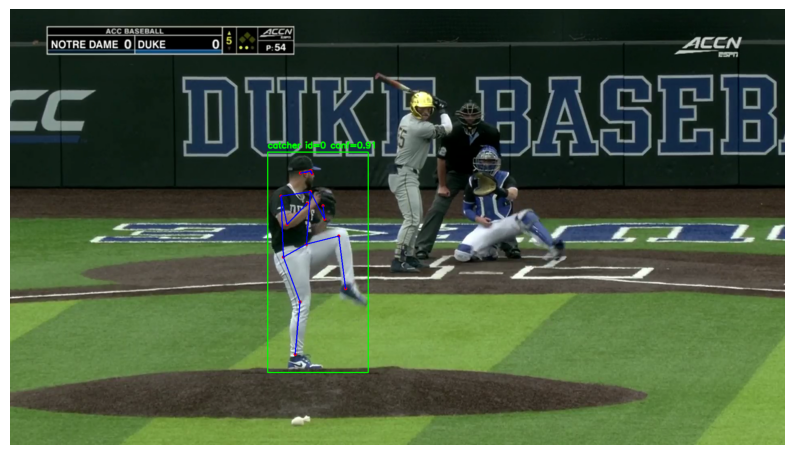

In [56]:
# Display ONLY the selected catcher for the chosen frame

import matplotlib.pyplot as plt
import cv2

SKELETON = [
    (0,1), (0,2), (1,3), (2,4),
    (5,6),
    (5,7), (7,9),
    (6,8), (8,10),
    (5,11), (6,12),
    (11,12),
    (11,13), (13,15),
    (12,14), (14,16)
]

# Always copy the stored frame so you do not modify the original
img = res[FRAME_INDEX]["frame"].copy()

# Recompute catcher for this frame in case FRAME_INDEX changed
catcher = select_catcher_pose_aware(res[FRAME_INDEX]["result"], debug=False)

if catcher is not None:
    x1, y1, x2, y2 = catcher["box"].astype(int)
    kpts = catcher["keypoints"]

    # Draw ONLY the selected catcher box
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Optional label
    label = f"catcher id={catcher['index']} conf={float(catcher['confidence']):.2f}"
    cv2.putText(
        img,
        label,
        (x1, max(30, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2,
        cv2.LINE_AA
    )

    # Draw ONLY the selected catcher keypoints
    for x, y in kpts:
        cv2.circle(img, (int(x), int(y)), 4, (0, 0, 255), -1)

    # Draw ONLY the selected catcher skeleton
    for i, j in SKELETON:
        x1p, y1p = kpts[i]
        x2p, y2p = kpts[j]
        cv2.line(img, (int(x1p), int(y1p)), (int(x2p), int(y2p)), (255, 0, 0), 2)
else:
    cv2.putText(
        img,
        "No catcher found",
        (30, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [57]:
# Run catcher detection on ALL frames and save an annotated video.
# If no catcher is found on a frame, nothing is drawn on that frame.

import cv2
import matplotlib.pyplot as plt
from pathlib import Path

SKELETON = [
    (0,1), (0,2), (1,3), (2,4),
    (5,6),
    (5,7), (7,9),
    (6,8), (8,10),
    (5,11), (6,12),
    (11,12),
    (11,13), (13,15),
    (12,14), (14,16)
]

OUTPUT_VIDEO = "catcher_annotated.mp4"
FPS = 30  # change if you know the source fps

annotated_frames = []

for frame_idx in range(len(res)):
    frame = res[frame_idx]["frame"].copy()
    result = res[frame_idx]["result"]

    catcher = select_catcher_pose_aware(result, debug=False)

    if catcher is not None:
        x1, y1, x2, y2 = catcher["box"].astype(int)
        kpts = catcher["keypoints"]

        # Draw only when a catcher is found
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

        label = f"catcher id={catcher['index']} conf={float(catcher['confidence']):.2f}"
        cv2.putText(
            frame,
            label,
            (x1, max(30, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

        for x, y in kpts:
            cv2.circle(frame, (int(x), int(y)), 4, (0, 0, 255), -1)

        for i, j in SKELETON:
            x1p, y1p = kpts[i]
            x2p, y2p = kpts[j]
            cv2.line(frame, (int(x1p), int(y1p)), (int(x2p), int(y2p)), (255, 0, 0), 2)

    annotated_frames.append(frame)

# Save video
h, w = annotated_frames[0].shape[:2]
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, FPS, (w, h))

for frame in annotated_frames:
    writer.write(frame)

writer.release()

print(f"Saved annotated video to: {OUTPUT_VIDEO}")
print(f"Total frames processed: {len(annotated_frames)}")

Saved annotated video to: catcher_annotated.mp4
Total frames processed: 270


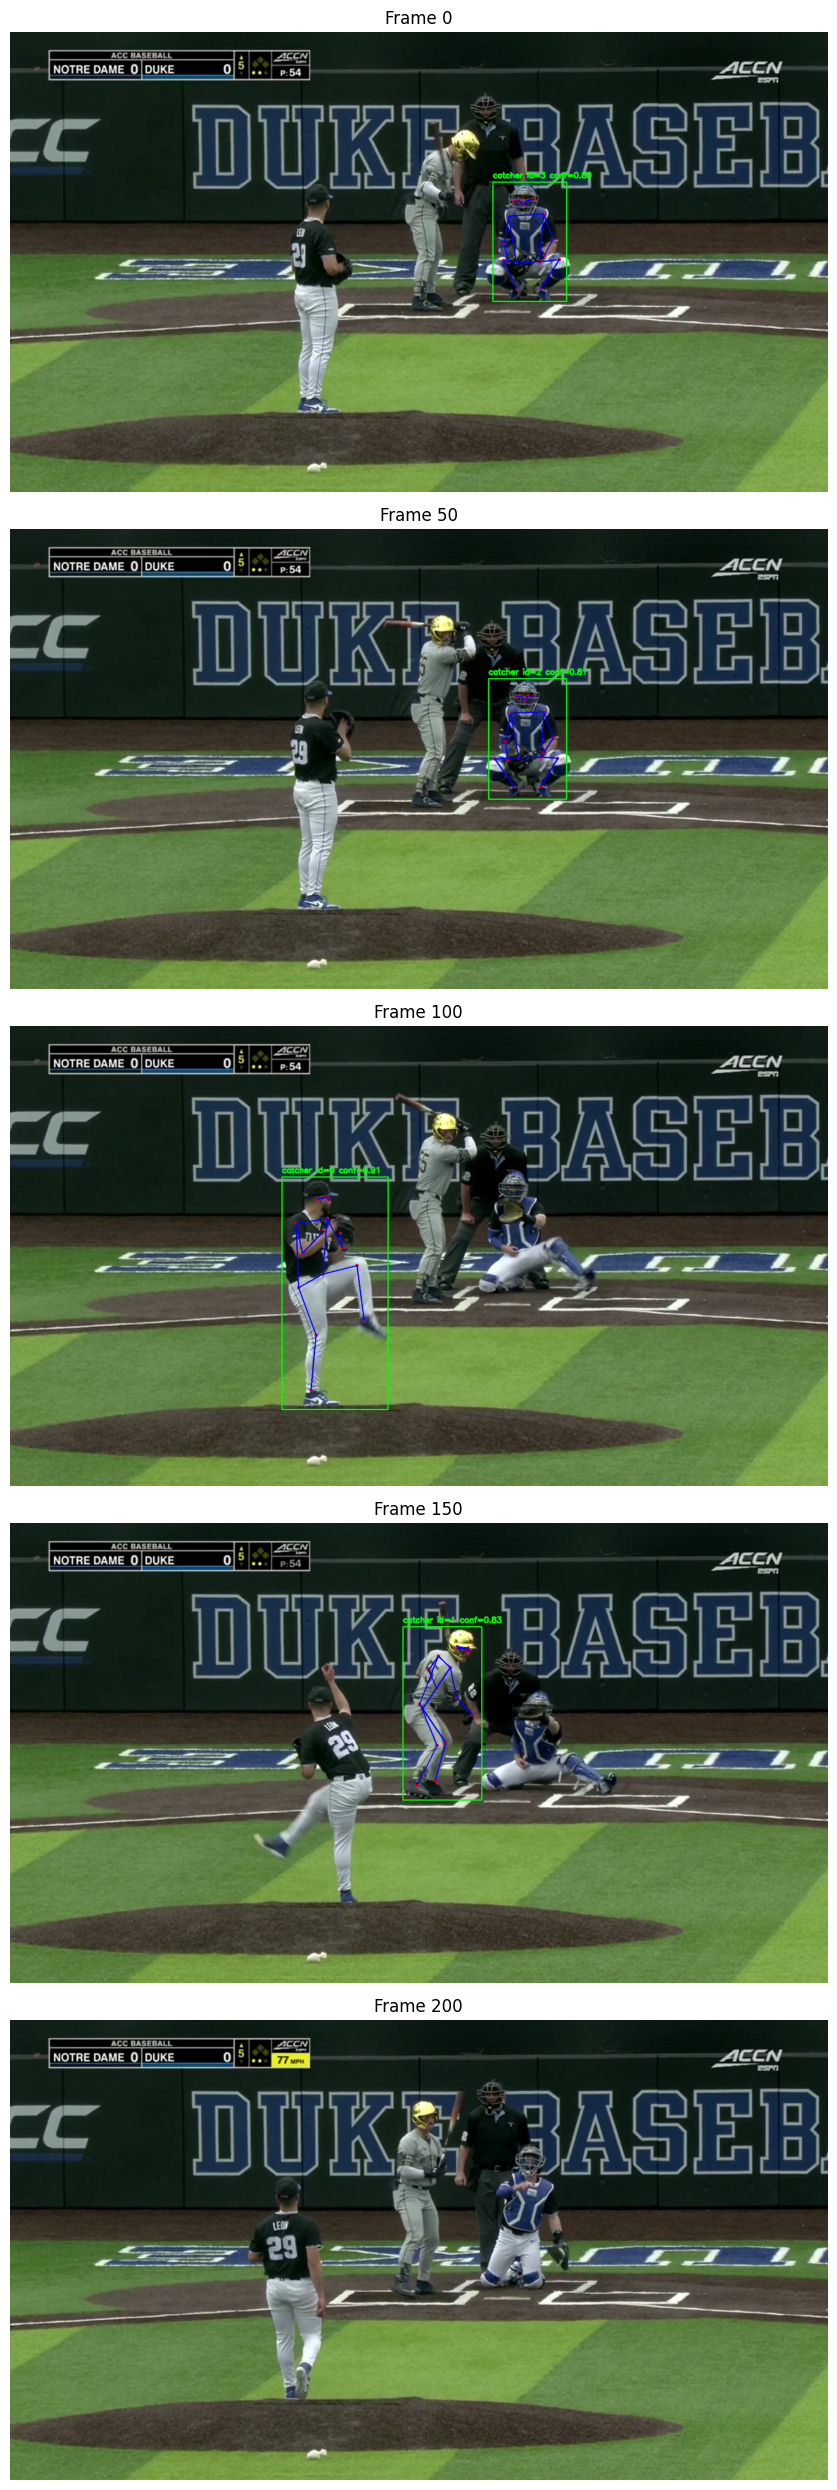

In [58]:
# Preview a few annotated frames inline

preview_indices = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(len(preview_indices), 1, figsize=(12, 5 * len(preview_indices)))

if len(preview_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, preview_indices):
    img_rgb = cv2.cvtColor(annotated_frames[idx], cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()